In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from src import baseClasses, systemClasses, sensorClasses, muxClasses
import datetime
import numpy as np
from tqdm import tqdm
import pickle
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
plt.style.use("style.mplstyle")

In [3]:
dataset = baseClasses.Data()

In [4]:
mask = (
    ((dataset.data.index > datetime.datetime(2024, 4, 30)) & (dataset.data.index < datetime.datetime(2024, 12, 10)))
)

dataset.data = dataset.data.loc[mask]
dataset.err = dataset.err.loc[mask]

In [5]:
tgrad = systemClasses.System(dataset=dataset, name="TGRAD")
apa = systemClasses.System(dataset=dataset, name="APA")
prm = systemClasses.System(dataset=dataset, name="PRM")
pipe = systemClasses.System(dataset=dataset, name="PIPE")
pp = systemClasses.System(dataset=dataset, name="PP")
hawai = systemClasses.System(dataset=dataset, name="HAWAI")
ga1 = systemClasses.System(dataset=dataset, name="GA-1")
ga2 = systemClasses.System(dataset=dataset, name="GA-2")

Initializing GA-2 Sensors: 100%|██████████| 18/18 [00:05<00:00,  3.51sensor/s]


In [6]:
tgrad.calibrate(calibName="SECOND_POFF_EMPTY")
apa.calibrate(calibName="SECOND_POFF_EMPTY")
prm.calibrate(calibName="SECOND_POFF_OCTOBER")
pipe.calibrate(calibName="SECOND_POFF_OCTOBER")
pp.calibrate(calibName="SECOND_POFF_OCTOBER")
hawai.calibrate(calibName="SECOND_POFF_EMPTY")

Equalizing TGRAD Sensors:   0%|          | 0/48 [00:00<?, ?sensor/s]

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:15<00:00,  3.15sensor/s]
Calibrating TGRAD Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 48/48 [00:00<00:00, 52.14sensor/s]
Equalizing APA Sensors: 100%|██████████| 16/16 [00:02<00:00,  5.89sensor/s]
Calibrating APA Sensors - Calibration Name: SECOND_POFF_EMPTY: 100%|██████████| 16/16 [00:00<00:00, 94.50sensor/s]
Equalizing PRM Sensors: 100%|██████████| 6/6 [00:01<00:00,  3.89sensor/s]
Calibrating PRM Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 6/6 [00:00<00:00, 103.91sensor/s]
Equalizing PIPE Sensors: 100%|██████████| 12/12 [00:03<00:00,  3.92sensor/s]
Calibrating PIPE Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 12/12 [00:00<00:00, 74.51sensor/s]
Equalizing PP Sensors: 100%|██████████| 2/2 [00:00<00:00,  4.34sensor/s]
Calibrating PP Sensors - Calibration Name: SECOND_POFF_OCTOBER: 100%|██████████| 2/2 [00:00<00:00, 54.21sensor/s]
Equalizing HAWAI Sensors: 100%|██████████|

In [7]:
pressure = sensorClasses.Sensor(dataset=dataset, id=1011)
pressure.data = pressure.data.dropna()

/var/folders/2t/9f64gwx57z3375hyl7mpxd3h0000gn/T/ipykernel_24456/651367148.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  profile["temp"].loc[(profile["Y"]>3960)] -= 0.004


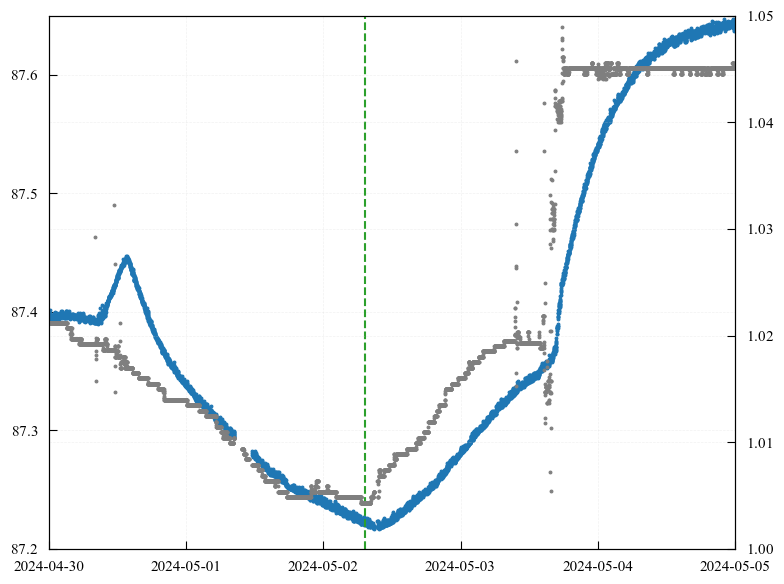

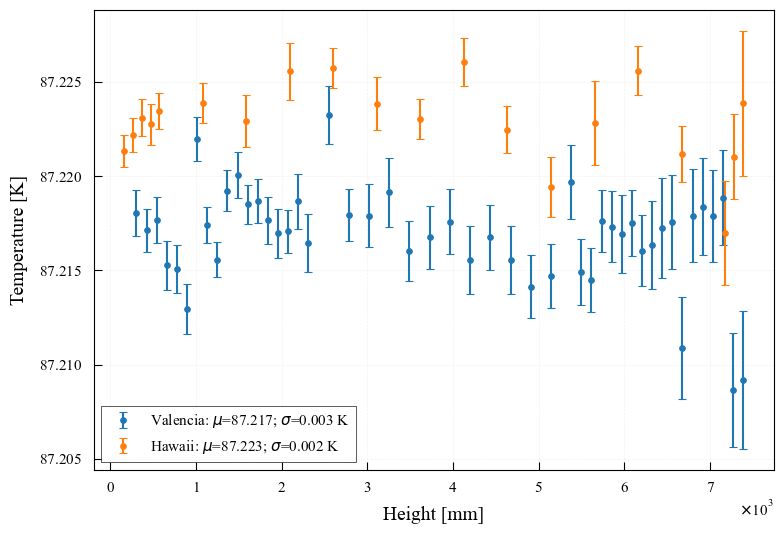

In [16]:
deltat = datetime.timedelta(minutes=60)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-04-30 00:00:00"), pd.Timestamp("2024-05-05 00:00:00"))
axes.set_ylim(87.2,87.65)
t1, color1 = pd.Timestamp("2024-5-2 9:40:00"), "tab:orange"
t2, color2 = pd.Timestamp("2024-5-2 7:21:00"), "tab:green"
# axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
axes2 = axes.twinx()
axes2.plot(pressure.data.index.values, pressure.data.values, ".", label="Pressure", color="tab:gray")
axes2.set_ylim(1, 1.05)
fig.tight_layout()

fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(6,6), sharex=True, sharey=True)
fig.set_size_inches(8, 5.5)

tgrad.makeProfiles(tini=t2, tend=t2 + deltat)
profile = tgrad.profiles
zero2 = profile["temp"].loc[(profile["Y"]==305)].values[0]
# profile["temp"].loc[(profile["Y"]>3960)] -= profile["temp"].loc[(profile["Y"]==3963)].values[0] - profile["temp"].loc[(profile["Y"]==3727)].values[0]
profile["temp"].loc[(profile["Y"]>3960)] -= 0.004
axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'Valencia: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:blue")

hawai.makeProfiles(tini=t2, tend=t2 + deltat)
profile = hawai.profiles

axes.errorbar(profile["Y"].values, profile["temp"].values, yerr=profile["err"].values, fmt='o', label=fr'Hawaii: $\mu$={profile["temp"].mean():.3f}; $\sigma$={profile["temp"].std():.3f} K', color="tab:orange")
axes.legend()
axes.set_xlabel("Height [mm]")
axes.set_ylabel("Temperature [K]")
fig.tight_layout()

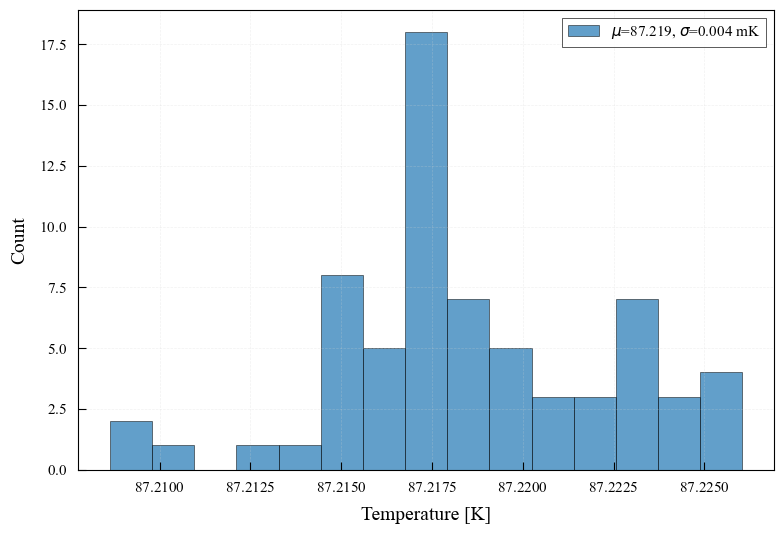

In [17]:
# Join tgrad.profiles and hawai.profiles on their indexes, suffixing columns to distinguish
joined_profiles = tgrad.profiles[["Y", "temp"]].rename(columns={"temp": "temp_tgrad"}).merge(
    hawai.profiles[["Y", "temp"]].rename(columns={"temp": "temp_hawai"}),
    on="Y",
    how="outer"
)

# Flatten the temperature columns into a single array, dropping NaNs
temps = pd.concat([
    joined_profiles["temp_tgrad"].dropna(),
    joined_profiles["temp_hawai"].dropna()
])

# Plot histogram
plt.figure(figsize=(8, 5.5))
plt.hist(temps, bins=15, color="tab:blue", alpha=0.7, label=fr"$\mu$={temps.mean():.3f}, $\sigma$={temps.std():.3f} mK", edgecolor='black')
plt.xlabel("Temperature [K]")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

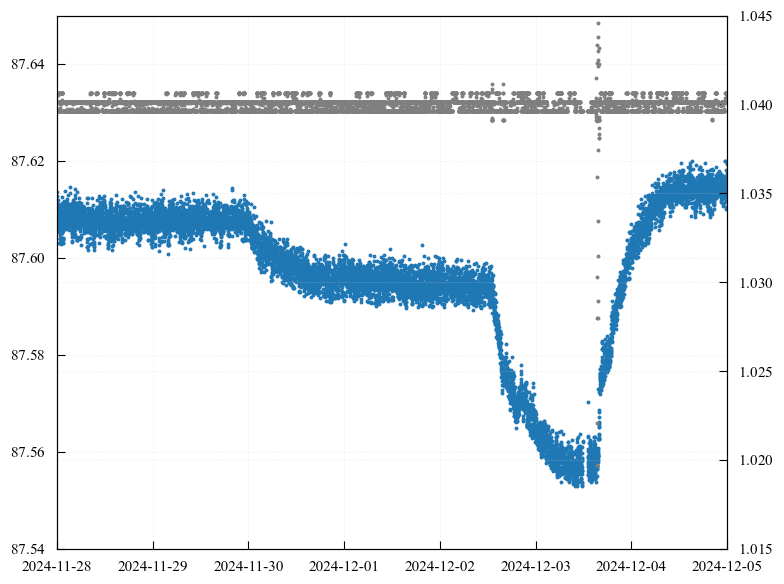

In [18]:
deltat = datetime.timedelta(minutes=60)
fig, axes = plt.subplots(nrows=1, ncols=1, figsize=(8, 6), sharex=True, sharey=True)
axes.plot(tgrad.sensors[39644].data.index.values, tgrad.sensors[39644].data.values, ".", label="TGRAD 39644", color="tab:blue")
axes.set_xlim(pd.Timestamp("2024-11-28 00:00:00"), pd.Timestamp("2024-12-05 00:00:00"))
axes.set_ylim(87.54,87.65)
# axes.axvline(t1, color=color1, linestyle="--", label=f"{t1}")
axes.axvline(t2, color=color2, linestyle="--", label=f"{t2}")
axes2 = axes.twinx()
axes2.plot(pressure.data.index.values, pressure.data.values, ".", label="Pressure", color="tab:gray")
axes2.set_ylim(1.015, 1.045)
fig.tight_layout()

In [19]:
tgrad.calibrate(calibName="FIRST_POFF_PIPES")

Equalizing TGRAD Sensors: 100%|██████████| 48/48 [00:11<00:00,  4.11sensor/s]
Calibrating TGRAD Sensors - Calibration Name: FIRST_POFF_PIPES: 100%|██████████| 48/48 [00:00<00:00, 72.20sensor/s]


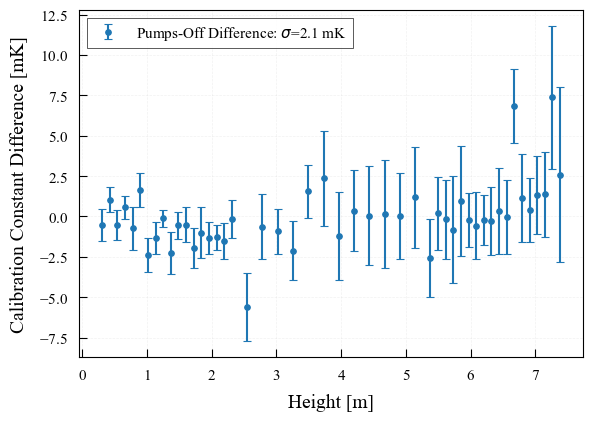

In [21]:
fig, axes = plt.subplots(nrows=1, ncols=1, sharex=True, sharey=True)
tgrad.makeProfiles(tini=pd.Timestamp("2024-12-03 11:35:00"), tend=pd.Timestamp("2024-12-03 11:45:00"))
axes.errorbar(
    1e-3*tgrad.profiles["Y"].values,
    1e3*tgrad.profiles["temp"].values - 1e3*tgrad.profiles["temp"].values.mean(),
    yerr=1e3*tgrad.profiles["err"].values,
    fmt='o',
    label=fr'Pumps-Off Difference: $\sigma$={1e3*tgrad.profiles["temp"].std():.1f} mK',
    color="tab:blue"
)
axes.legend()
axes.set_xlabel("Height [m]")
axes.set_ylabel("Calibration Constant Difference [mK]")
fig.savefig("/Users/jcapo/cernbox/DUNE-IFIC/Publications/NP04_TMS/CALIBRATION/poff_difference.png", format="png")